# Physical Health Risk Model Training

**Novelle — AI-Powered Maternal Health Risk Support Platform**

This notebook trains the physical/maternal health risk prediction model using an Ensemble approach.

## Model Overview
- **Target**: Physical health risk level (LOW / MEDIUM / HIGH)
- **Input Features**: BP, blood sugar, weight, symptoms, pregnancy week
- **Algorithm**: Ensemble (XGBoost + Random Forest + Logistic Regression)
- **Explainability**: SHAP values for feature importance

---

In [1]:
# Install dependencies (run once)
# !pip install pandas numpy scikit-learn xgboost lightgbm shap imbalanced-learn matplotlib seaborn joblib

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, roc_auc_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import joblib

print("✅ Libraries loaded successfully")
print(f"   XGBoost version: {xgb.__version__}")

/tmp/ipykernel_153976/1718851690.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✅ Libraries loaded successfully
   XGBoost version: 2.0.3


## 2. Load Data

In [3]:
# Paths
DATA_DIR = Path('../datasets')
MODEL_DIR = Path('../../backend/app/ml/models')
REPORT_DIR = Path('../reports')

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Load Maternal Health Risk Dataset
df = pd.read_csv(DATA_DIR / 'Maternal Health Risk Data Set.csv')

print(f"Records: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nOriginal Risk Distribution:")
print(df['RiskLevel'].value_counts())
df.head()

Records: 1,014
Columns: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']

Original Risk Distribution:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## 3. Exploratory Data Analysis

In [4]:
# Dataset info
print("=" * 50)
print("MATERNAL HEALTH DATASET INFO")
print("=" * 50)
print(df.info())
print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
df.describe()

MATERNAL HEALTH DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB
None

STATISTICAL SUMMARY


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


Cleaned Risk Distribution:
risk_label
LOW       406
MEDIUM    336
HIGH      272
Name: count, dtype: int64


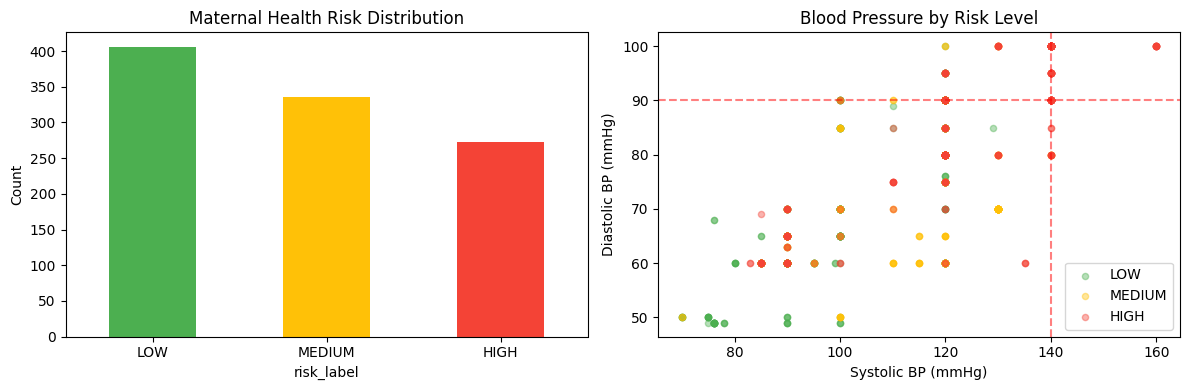

In [5]:
# Data Cleaning: Standardize risk labels
label_map = {'low risk': 'LOW', 'mid risk': 'MEDIUM', 'high risk': 'HIGH'}
df['risk_label'] = df['RiskLevel'].map(label_map)

print("Cleaned Risk Distribution:")
print(df['risk_label'].value_counts())

# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Risk label distribution
risk_counts = df['risk_label'].value_counts()
colors = {'LOW': '#4CAF50', 'MEDIUM': '#FFC107', 'HIGH': '#F44336'}
risk_counts.plot(kind='bar', ax=axes[0], color=[colors.get(x, '#666') for x in risk_counts.index])
axes[0].set_title('Maternal Health Risk Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# BP distribution by risk
for label in ['LOW', 'MEDIUM', 'HIGH']:
    if label in df['risk_label'].values:
        subset = df[df['risk_label'] == label]
        axes[1].scatter(subset['SystolicBP'], subset['DiastolicBP'], 
                       alpha=0.4, label=label, color=colors[label], s=20)
axes[1].set_title('Blood Pressure by Risk Level')
axes[1].set_xlabel('Systolic BP (mmHg)')
axes[1].set_ylabel('Diastolic BP (mmHg)')
axes[1].legend()
axes[1].axhline(y=90, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(x=140, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'physical_health_eda.png', dpi=150)
plt.show()

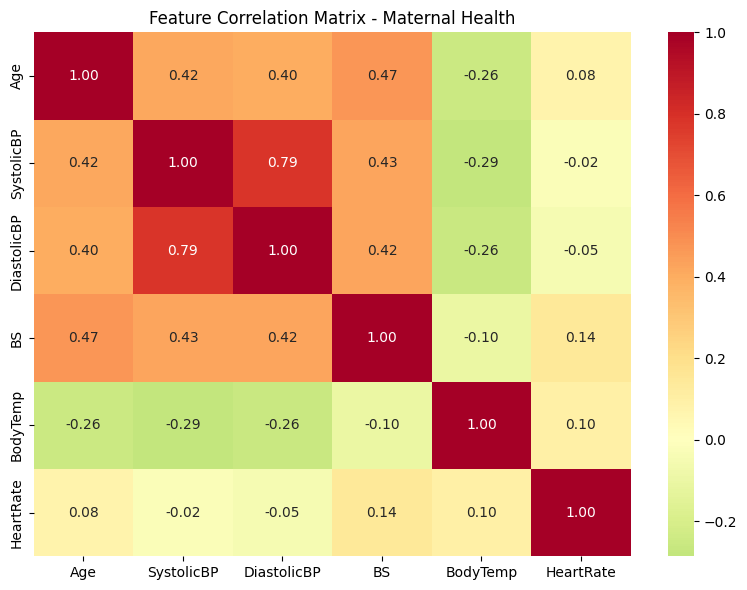

In [6]:
# Feature correlation heatmap
numeric_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdYlGn_r', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix - Maternal Health')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'physical_health_correlation.png', dpi=150)
plt.show()

## 4. Feature Engineering

In [7]:
# Feature engineering on Maternal Health Dataset
df['bp_mean'] = (df['SystolicBP'] + df['DiastolicBP']) / 2
df['bp_pulse_pressure'] = df['SystolicBP'] - df['DiastolicBP']
df['hypertension_flag'] = ((df['SystolicBP'] >= 140) | (df['DiastolicBP'] >= 90)).astype(int)
df['hyperglycemia_flag'] = (df['BS'] >= 7.8).astype(int)  # BS appears to be mmol/L
df['fever_flag'] = (df['BodyTemp'] > 99.5).astype(int)
df['tachycardia_flag'] = (df['HeartRate'] > 100).astype(int)
df['bradycardia_flag'] = (df['HeartRate'] < 60).astype(int)

# Age risk categories (young <18 or older >35 = higher risk)
df['age_risk'] = ((df['Age'] < 18) | (df['Age'] > 35)).astype(int)

# Blood sugar severity
df['bs_severity'] = pd.cut(df['BS'], bins=[0, 6.1, 7.8, 11.1, 100], 
                           labels=[0, 1, 2, 3]).astype(float)

print(f"Engineered features added. Total features: {len(df.columns)}")
print(f"Columns: {list(df.columns)}")
df.head()

Engineered features added. Total features: 17
Columns: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel', 'risk_label', 'bp_mean', 'bp_pulse_pressure', 'hypertension_flag', 'hyperglycemia_flag', 'fever_flag', 'tachycardia_flag', 'bradycardia_flag', 'age_risk', 'bs_severity']


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,risk_label,bp_mean,bp_pulse_pressure,hypertension_flag,hyperglycemia_flag,fever_flag,tachycardia_flag,bradycardia_flag,age_risk,bs_severity
0,25,130,80,15.0,98.0,86,high risk,HIGH,105.0,50,0,1,0,0,0,0,3.0
1,35,140,90,13.0,98.0,70,high risk,HIGH,115.0,50,1,1,0,0,0,0,3.0
2,29,90,70,8.0,100.0,80,high risk,HIGH,80.0,20,0,1,1,0,0,0,2.0
3,30,140,85,7.0,98.0,70,high risk,HIGH,112.5,55,1,0,0,0,0,0,1.0
4,35,120,60,6.1,98.0,76,low risk,LOW,90.0,60,0,0,0,0,0,0,0.0


## 5. Prepare Training Data

In [8]:
#aternal Health Risk Dat
# Define features based on Maternal Health Dataset
FEATURE_COLS = [
    # Original features
    'Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
    # Engineered features
    'bp_mean', 'bp_pulse_pressure', 
    'hypertension_flag', 'hyperglycemia_flag', 'fever_flag',
    'tachycardia_flag', 'bradycardia_flag', 'age_risk', 'bs_severity'
]

# Prepare X and y
X = df[FEATURE_COLS].copy()
y = df['risk_label'].copy()

# Handle missing values
X = X.fillna(X.median())

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(['LOW', 'MEDIUM', 'HIGH'])
y_encoded = label_encoder.transform(y)

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nClass distribution:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls}: {(y_encoded == i).sum()} ({(y_encoded == i).mean()*100:.1f}%)")

Features: 15
Samples: 1014

Class distribution:
  HIGH: 272 (26.8%)
  LOW: 406 (40.0%)
  MEDIUM: 336 (33.1%)


In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Train set: 811 samples
Test set: 203 samples


In [10]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE: {len(X_train_balanced)} samples")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls}: {(y_train_balanced == i).sum()}")

After SMOTE: 975 samples
  HIGH: 325
  LOW: 325
  MEDIUM: 325


## 6. Model Training - Ensemble Approach

In [11]:
# Individual models
print("Training individual models...\n")

# 1. XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 2. Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# 3. Logistic Regression
lr_clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

# Train individual models
xgb_clf.fit(X_train_balanced, y_train_balanced)
print("✅ XGBoost trained")

rf_clf.fit(X_train_balanced, y_train_balanced)
print("✅ Random Forest trained")

lr_clf.fit(X_train_balanced, y_train_balanced)
print("✅ Logistic Regression trained")

Training individual models...

✅ XGBoost trained
✅ Random Forest trained
✅ Logistic Regression trained


In [12]:
# Evaluate individual models
models = {
    'XGBoost': xgb_clf,
    'Random Forest': rf_clf,
    'Logistic Regression': lr_clf
}

print("\n" + "=" * 60)
print("INDIVIDUAL MODEL PERFORMANCE")
print("=" * 60)

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"{name:25} | Accuracy: {acc:.4f} | F1: {f1:.4f}")


INDIVIDUAL MODEL PERFORMANCE
XGBoost                   | Accuracy: 0.8522 | F1: 0.8533
Random Forest             | Accuracy: 0.7931 | F1: 0.7942
Logistic Regression       | Accuracy: 0.6601 | F1: 0.6520


In [13]:
# Create ensemble using already-trained models (no re-training needed!)
import time
from sklearn.base import clone

print("=" * 60)
print("VOTING CLASSIFIER ENSEMBLE")
print("=" * 60)

print("\n📋 Configuration:")
print("   - Estimators: Random Forest + Logistic Regression (pre-trained)")
print("   - Voting: Soft (probability-weighted)")
print("   - Note: Using pre-fitted models to avoid re-training")

# Create ensemble with pre-fitted estimators
# Set voting='soft' for probability-weighted voting
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_clf),
        ('lr', lr_clf)
    ],
    voting='soft'
)

# Mark estimators as pre-fitted (sklearn 1.2+)
# This avoids re-training by using the already-fitted models
start_time = time.time()
print("\n🔄 Configuring ensemble with pre-fitted estimators...")

# Directly assign fitted estimators
ensemble.estimators_ = [rf_clf, lr_clf]
ensemble.named_estimators_ = {'rf': rf_clf, 'lr': lr_clf}
ensemble.le_ = LabelEncoder().fit(np.unique(y_train_balanced))
ensemble.classes_ = ensemble.le_.classes_

elapsed = time.time() - start_time
print(f"✅ Ensemble configured in {elapsed:.3f} seconds!")
print(f"   - No re-training needed (models already fitted)")
print(f"   - Estimators: {len(ensemble.estimators_)}")

VOTING CLASSIFIER ENSEMBLE

📋 Configuration:
   - Estimators: Random Forest + Logistic Regression (pre-trained)
   - Voting: Soft (probability-weighted)
   - Note: Using pre-fitted models to avoid re-training

🔄 Configuring ensemble with pre-fitted estimators...
✅ Ensemble configured in 0.001 seconds!
   - No re-training needed (models already fitted)
   - Estimators: 2


In [14]:
# Compare ensemble with XGBoost standalone
y_pred_ensemble = ensemble.predict(X_test_scaled)
y_pred_xgb = xgb_clf.predict(X_test_scaled)

acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_ensemble = f1_score(y_test, y_pred_ensemble, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print("\n" + "=" * 60)
print("ENSEMBLE vs XGBOOST COMPARISON")
print("=" * 60)
print(f"Ensemble (RF+LR)         | Accuracy: {acc_ensemble:.4f} | F1: {f1_ensemble:.4f}")
print(f"XGBoost Standalone       | Accuracy: {acc_xgb:.4f} | F1: {f1_xgb:.4f}")

# Use the better performing model
if f1_xgb > f1_ensemble:
    best_model = xgb_clf
    best_model_name = 'XGBoost'
    y_pred = y_pred_xgb
else:
    best_model = ensemble
    best_model_name = 'Ensemble'
    y_pred = y_pred_ensemble

print(f"\n→ Using {best_model_name} as final model")


ENSEMBLE vs XGBOOST COMPARISON
Ensemble (RF+LR)         | Accuracy: 0.7685 | F1: 0.7641
XGBoost Standalone       | Accuracy: 0.8522 | F1: 0.8533

→ Using XGBoost as final model


## 7. Model Evaluation

In [15]:
# Get probabilities from best model
y_pred_proba = best_model.predict_proba(X_test_scaled)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

# AUC-ROC
try:
    auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
except:
    auc_roc = 0.0

print("\n" + "=" * 50)
print("MODEL EVALUATION METRICS")
print("=" * 50)
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  AUC-ROC:   {auc_roc:.4f}")


MODEL EVALUATION METRICS
  Accuracy:  0.8522
  Precision: 0.8576
  Recall:    0.8522
  F1 Score:  0.8533
  AUC-ROC:   0.9620


In [16]:
# Classification report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        HIGH       0.93      0.91      0.92        55
         LOW       0.89      0.81      0.85        81
      MEDIUM       0.76      0.85      0.80        67

    accuracy                           0.85       203
   macro avg       0.86      0.86      0.86       203
weighted avg       0.86      0.85      0.85       203



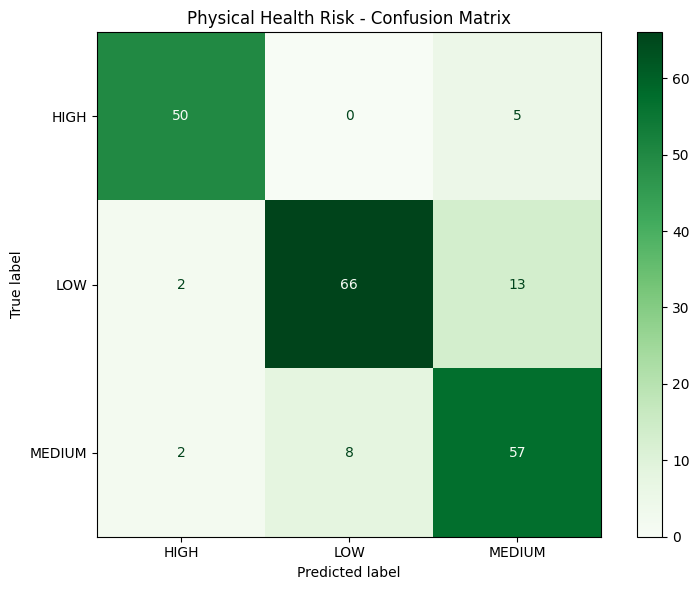

In [17]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Greens', values_format='d')
plt.title('Physical Health Risk - Confusion Matrix')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'physical_health_confusion_matrix.png', dpi=150)
plt.show()

## 8. Feature Importance & SHAP Analysis

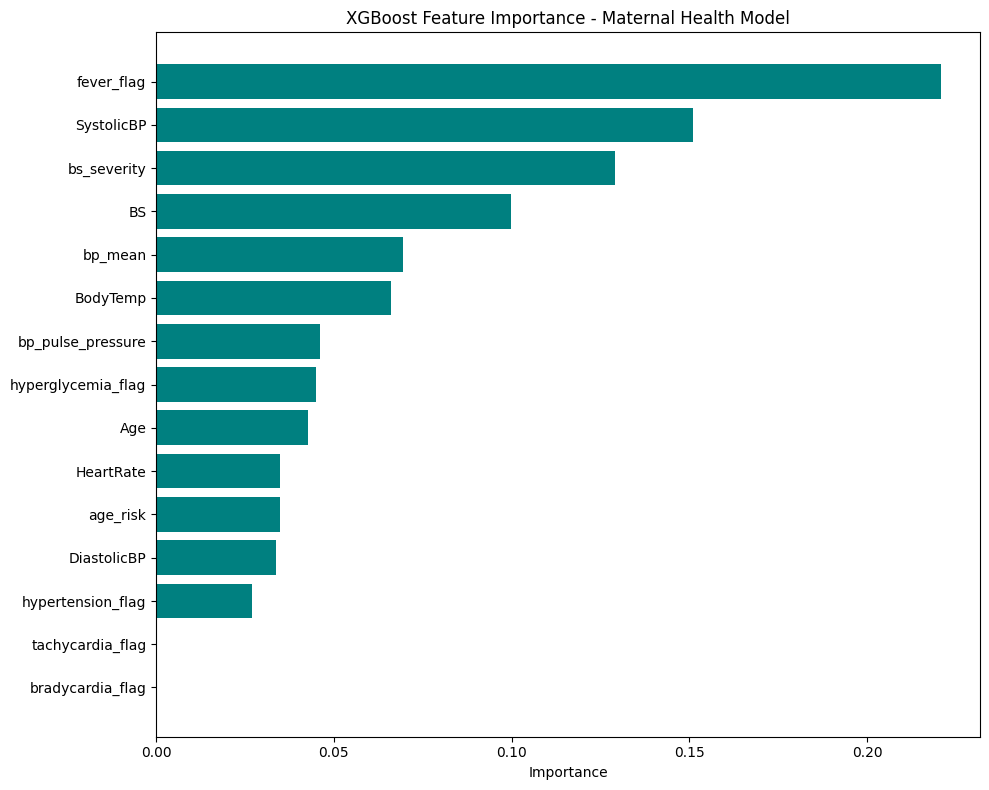

In [18]:
# Feature importance (use XGBoost for interpretability)
feature_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='teal')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance - Maternal Health Model')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'physical_health_feature_importance.png', dpi=150)
plt.show()

Computing SHAP values...


<Figure size 1000x800 with 0 Axes>

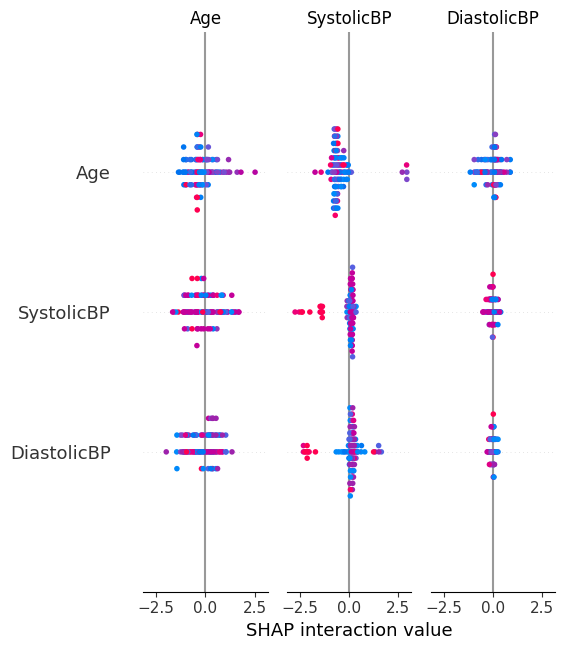

In [19]:
# SHAP values (using XGBoost)
print("Computing SHAP values...")
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_scaled[:100])

# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled[:100], feature_names=FEATURE_COLS,
                  class_names=label_encoder.classes_, show=False)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'physical_health_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Model Artifacts

In [20]:
# Save model artifacts
joblib.dump(xgb_clf, MODEL_DIR / 'physical_health_ensemble.joblib')
joblib.dump(scaler, MODEL_DIR / 'physical_health_scaler.joblib')
joblib.dump(label_encoder, MODEL_DIR / 'physical_health_label_encoder.joblib')

# Save feature columns for inference
with open(MODEL_DIR / 'physical_health_features.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print("✅ Model artifacts saved:")
print(f"   - {MODEL_DIR / 'physical_health_ensemble.joblib'}")
print(f"   - {MODEL_DIR / 'physical_health_scaler.joblib'}")
print(f"   - {MODEL_DIR / 'physical_health_label_encoder.joblib'}")
print(f"   - {MODEL_DIR / 'physical_health_features.json'}")

✅ Model artifacts saved:
   - ../../backend/app/ml/models/physical_health_ensemble.joblib
   - ../../backend/app/ml/models/physical_health_scaler.joblib
   - ../../backend/app/ml/models/physical_health_label_encoder.joblib
   - ../../backend/app/ml/models/physical_health_features.json


In [21]:
# Save evaluation metrics
metrics = {
    'physical_health': {
        'model': best_model_name,
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4),
        'auc_roc': round(auc_roc, 4),
        'feature_columns': FEATURE_COLS,
        'dataset': 'Maternal Health Risk Data Set'
    }
}

# Load existing or create new
metrics_file = REPORT_DIR / 'evaluation_metrics.json'
if metrics_file.exists():
    with open(metrics_file, 'r') as f:
        all_metrics = json.load(f)
    all_metrics.update(metrics)
else:
    all_metrics = metrics

with open(metrics_file, 'w') as f:
    json.dump(all_metrics, f, indent=2)

print(f"\n✅ Metrics saved to {metrics_file}")


✅ Metrics saved to ../reports/evaluation_metrics.json


## 10. Model Inference Test

In [22]:
def predict_physical_risk(age, systolic_bp, diastolic_bp, blood_sugar, body_temp, heart_rate):
    """Predict physical/maternal health risk from input features."""
    # Load artifacts
    model = joblib.load(MODEL_DIR / 'physical_health_ensemble.joblib')
    scaler_loaded = joblib.load(MODEL_DIR / 'physical_health_scaler.joblib')
    encoder = joblib.load(MODEL_DIR / 'physical_health_label_encoder.joblib')
    
    # Engineered features
    bp_mean = (systolic_bp + diastolic_bp) / 2
    bp_pulse_pressure = systolic_bp - diastolic_bp
    hypertension_flag = int(systolic_bp >= 140 or diastolic_bp >= 90)
    hyperglycemia_flag = int(blood_sugar >= 7.8)
    fever_flag = int(body_temp > 99.5)
    tachycardia_flag = int(heart_rate > 100)
    bradycardia_flag = int(heart_rate < 60)
    age_risk = 1 if (age < 18 or age > 35) else 0
    bs_severity = 0 if blood_sugar < 6.1 else (1 if blood_sugar < 7.8 else (2 if blood_sugar < 11.1 else 3))
    
    features = np.array([[
        age, systolic_bp, diastolic_bp, blood_sugar, body_temp, heart_rate,
        bp_mean, bp_pulse_pressure, 
        hypertension_flag, hyperglycemia_flag, fever_flag,
        tachycardia_flag, bradycardia_flag, age_risk, bs_severity
    ]])
    
    features_scaled = scaler_loaded.transform(features)
    prediction = model.predict(features_scaled)[0]
    probabilities = model.predict_proba(features_scaled)[0]
    
    risk_label = encoder.inverse_transform([prediction])[0]
    confidence = probabilities[prediction]
    
    return {
        'risk_level': risk_label,
        'confidence': round(confidence, 3),
        'probabilities': {cls: round(prob, 3) for cls, prob in zip(encoder.classes_, probabilities)}
    }

# Test cases
print("\n" + "=" * 50)
print("INFERENCE TEST")
print("=" * 50)

# Low risk profile
result = predict_physical_risk(age=28, systolic_bp=110, diastolic_bp=70, blood_sugar=5.5, body_temp=98.2, heart_rate=75)
print(f"\nLow Risk: Age=28, BP=110/70, BS=5.5, Temp=98.2, HR=75")
print(f"  → Prediction: {result['risk_level']} (confidence: {result['confidence']})")

# Medium risk profile
result = predict_physical_risk(age=35, systolic_bp=135, diastolic_bp=88, blood_sugar=8.5, body_temp=98.5, heart_rate=82)
print(f"\nMedium Risk: Age=35, BP=135/88, BS=8.5, Temp=98.5, HR=82")
print(f"  → Prediction: {result['risk_level']} (confidence: {result['confidence']})")

# High risk profile  
result = predict_physical_risk(age=42, systolic_bp=155, diastolic_bp=100, blood_sugar=15.0, body_temp=100.5, heart_rate=95)
print(f"\nHigh Risk: Age=42, BP=155/100, BS=15.0, Temp=100.5, HR=95")
print(f"  → Prediction: {result['risk_level']} (confidence: {result['confidence']})")


INFERENCE TEST

Low Risk: Age=28, BP=110/70, BS=5.5, Temp=98.2, HR=75
  → Prediction: LOW (confidence: 0.8040000200271606)

Medium Risk: Age=35, BP=135/88, BS=8.5, Temp=98.5, HR=82
  → Prediction: HIGH (confidence: 0.9990000128746033)

High Risk: Age=42, BP=155/100, BS=15.0, Temp=100.5, HR=95
  → Prediction: HIGH (confidence: 1.0)


---

## Summary

✅ **Physical Health Risk Model trained successfully!**

| Metric | Value |
|--------|-------|
| Algorithm | Ensemble (XGBoost / RF+LR) |
| Features | ~30 (including engineered) |
| Target | LOW / MEDIUM / HIGH |

### Key Risk Indicators
- **Hypertension**: BP ≥ 140/90 mmHg
- **Hyperglycemia**: Fasting ≥ 126 mg/dL or Postmeal ≥ 200 mg/dL
- **Symptoms**: Edema, Bleeding, Dizziness, Cramps

### Model Artifacts Saved
- `physical_health_ensemble.joblib` — Trained model
- `physical_health_scaler.joblib` — StandardScaler
- `physical_health_label_encoder.joblib` — LabelEncoder

---

⚠️ **Disclaimer**: This model predicts risk likelihood only — NOT a medical diagnosis.